# WFCRL Synthetic Graph PFN Sandbox
Synthetic wake-graph dataset + baselines + PFN-style in-context graph regressor scaffold.


## 0) Install dependencies
Skip if already installed. `torch-geometric` install varies by OS/CUDA.


In [1]:
# If running locally, uncomment as needed.
# !pip install -U numpy torch tabpfn
# For torch-geometric, follow:
# https://pytorch-geometric.readthedocs.io/en/latest/install/installation.html

import numpy as np


## 1) Synthetic wake graph generator

In [2]:
from __future__ import annotations
import math
import numpy as np
from dataclasses import dataclass
from typing import Tuple, List

@dataclass
class GraphSample:
    x: np.ndarray              # (N, F)
    edge_index: np.ndarray     # (2, E)
    edge_attr: np.ndarray      # (E, A)
    y_total: float
    y_node: np.ndarray         # (N,)

def _angle_wrap_deg(a: float) -> float:
    return (a + 360.0) % 360.0

def _angle_diff_deg(a: float, b: float) -> float:
    d = (a - b + 180.0) % 360.0 - 180.0
    return abs(d)

def _bearing_deg(dx: float, dy: float) -> float:
    # 0 deg = +y (north), 90 deg = +x (east)
    return _angle_wrap_deg(math.degrees(math.atan2(dx, dy)))

def build_wake_graph(
    xy: np.ndarray,
    wind_dir_deg: float,
    dist_thresh: float = 1200.0,
    cone_deg: float = 45.0,
) -> Tuple[np.ndarray, np.ndarray]:
    n = xy.shape[0]
    src, dst, eattr = [], [], []
    downwind = _angle_wrap_deg(wind_dir_deg + 180.0)

    for i in range(n):
        xi, yi = xy[i]
        for j in range(n):
            if i == j:
                continue
            xj, yj = xy[j]
            dx, dy = float(xj - xi), float(yj - yi)
            d = math.hypot(dx, dy)
            if d > dist_thresh:
                continue
            b = _bearing_deg(dx, dy)
            if _angle_diff_deg(b, downwind) <= cone_deg:
                src.append(i)
                dst.append(j)
                eattr.append([d, _angle_diff_deg(b, downwind), d / dist_thresh])

    edge_index = np.asarray([src, dst], dtype=np.int64)
    edge_attr  = np.asarray(eattr, dtype=np.float32) if len(eattr) else np.zeros((0, 3), np.float32)
    return edge_index, edge_attr

def jensen_like_power(
    xy: np.ndarray,
    yaw_deg: np.ndarray,
    wind_speed: float,
    wind_dir_deg: float,
    rotor_diam: float = 126.0,
    ct: float = 0.8,
    k_wake: float = 0.05,
    base_eff: float = 1.0,
) -> np.ndarray:
    n = xy.shape[0]
    ws = wind_speed
    wd = wind_dir_deg
    downwind = _angle_wrap_deg(wd + 180.0)

    th = math.radians(downwind)
    ux, uy = math.sin(th), math.cos(th)

    deficits2 = np.zeros(n, dtype=np.float64)

    yaw_rad = np.deg2rad(yaw_deg)
    yaw_gain = np.cos(yaw_rad) ** 1.88

    for i in range(n):
        xi, yi = xy[i]
        for j in range(n):
            if i == j:
                continue
            xj, yj = xy[j]
            dx, dy = (xj - xi), (yj - yi)

            s = dx * ux + dy * uy
            if s <= 0:
                continue

            cwx = dx - s * ux
            cwy = dy - s * uy
            r = math.hypot(cwx, cwy)

            R = rotor_diam / 2.0 + k_wake * s
            if r > R:
                continue

            yaw_factor = (math.cos(yaw_rad[i]) ** 1.2)
            denom = (1.0 + 2.0 * k_wake * s / rotor_diam) ** 2
            d_ij = (1.0 - math.sqrt(1.0 - ct * yaw_factor)) / denom
            deficits2[j] += d_ij ** 2

    ws_eff = ws * (1.0 - np.sqrt(deficits2))
    ws_eff = np.clip(ws_eff, 0.0, None)

    p = base_eff * (ws_eff ** 3) * yaw_gain
    return p.astype(np.float32)

def sample_synthetic_graph(
    n_turbines: int = 9,
    layout: str = "random",
    area: float = 2000.0,
    wind_speed_range: Tuple[float, float] = (6.0, 12.0),
    wind_dir_range: Tuple[float, float] = (0.0, 360.0),
    yaw_range: Tuple[float, float] = (-25.0, 25.0),
    rng: np.random.Generator | None = None,
    ct: float = 0.8,
    k_wake: float = 0.05,
) -> GraphSample:
    rng = rng or np.random.default_rng()

    if layout == "grid":
        side = int(math.ceil(math.sqrt(n_turbines)))
        xs = np.linspace(0, area, side)
        ys = np.linspace(0, area, side)
        xy = np.array([(x, y) for x in xs for y in ys], dtype=np.float32)[:n_turbines]
    elif layout == "row":
        xy = np.stack([np.linspace(0, area, n_turbines), np.full(n_turbines, area * 0.5)], axis=1).astype(np.float32)
    else:
        xy = rng.uniform(0, area, size=(n_turbines, 2)).astype(np.float32)

    wind_speed = float(rng.uniform(*wind_speed_range))
    wind_dir = float(rng.uniform(*wind_dir_range))
    yaw = rng.uniform(*yaw_range, size=(n_turbines,)).astype(np.float32)

    edge_index, edge_attr = build_wake_graph(xy, wind_dir)

    x = np.column_stack([
        yaw,
        np.full(n_turbines, wind_speed, dtype=np.float32),
        np.full(n_turbines, wind_dir, dtype=np.float32),
        xy[:, 0],
        xy[:, 1],
    ]).astype(np.float32)

    p_node = jensen_like_power(xy, yaw, wind_speed, wind_dir, ct=ct, k_wake=k_wake)
    y_total = float(np.sum(p_node))
    return GraphSample(x=x, edge_index=edge_index, edge_attr=edge_attr, y_total=y_total, y_node=p_node)

def make_dataset(num_samples: int = 5000, n_turbines: int = 9, seed: int = 0) -> List[GraphSample]:
    rng = np.random.default_rng(seed)
    return [sample_synthetic_graph(n_turbines=n_turbines, rng=rng) for _ in range(num_samples)]

s = sample_synthetic_graph(n_turbines=9, layout="random", rng=np.random.default_rng(0))
print("x:", s.x.shape, "edge_index:", s.edge_index.shape, "edge_attr:", s.edge_attr.shape, "y_total:", s.y_total)
print("num edges:", s.edge_index.shape[1])


x: (9, 5) edge_index: (2, 13) edge_attr: (13, 3) y_total: 3145.595703125
num edges: 13


## 2) Graph baseline (GNN) on synthetic data

In [3]:
import torch
import torch.nn as nn

try:
    from torch_geometric.data import Data
    from torch_geometric.loader import DataLoader
    from torch_geometric.nn import GATv2Conv, global_mean_pool
except Exception as e:
    raise RuntimeError(
        "torch_geometric not available. Install PyTorch Geometric first.\n"
        "See: https://pytorch-geometric.readthedocs.io/en/latest/install/installation.html\n"
        f"Original error: {e}"
    )

def to_data(s: GraphSample) -> Data:
    return Data(
        x=torch.tensor(s.x, dtype=torch.float32),
        edge_index=torch.tensor(s.edge_index, dtype=torch.long),
        edge_attr=torch.tensor(s.edge_attr, dtype=torch.float32),
        y=torch.tensor([s.y_total], dtype=torch.float32),
    )

class GNNReg(nn.Module):
    def __init__(self, in_dim=5, hid=64):
        super().__init__()
        self.c1 = GATv2Conv(in_dim, hid, heads=2, concat=False, edge_dim=3)
        self.c2 = GATv2Conv(hid, hid, heads=2, concat=False, edge_dim=3)
        self.lin = nn.Sequential(nn.Linear(hid, hid), nn.ReLU(), nn.Linear(hid, 1))

    def forward(self, data: Data):
        h = self.c1(data.x, data.edge_index, data.edge_attr).relu()
        h = self.c2(h, data.edge_index, data.edge_attr).relu()
        g = global_mean_pool(h, data.batch)
        return self.lin(g).squeeze(-1)

ds = [to_data(s) for s in make_dataset(num_samples=3000, n_turbines=9, seed=0)]
tr, te = ds[:2600], ds[2600:]

tr_loader = DataLoader(tr, batch_size=64, shuffle=True)
te_loader = DataLoader(te, batch_size=256)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GNNReg().to(device)
opt = torch.optim.AdamW(model.parameters(), lr=3e-4)
loss_fn = nn.MSELoss()

for ep in range(15):
    model.train()
    for b in tr_loader:
        b = b.to(device)
        pred = model(b)
        loss = loss_fn(pred, b.y.view(-1))
        opt.zero_grad()
        loss.backward()
        opt.step()

    model.eval()
    with torch.no_grad():
        se = 0.0
        n = 0
        for b in te_loader:
            b = b.to(device)
            pred = model(b)
            se += torch.sum((pred - b.y.view(-1)) ** 2).item()
            n += b.num_graphs
        mse = se / n
    print(f"epoch={ep:02d} test_mse={mse:.4f} device={device}")


epoch=00 test_mse=41893281.2800 device=cpu
epoch=01 test_mse=34244600.3200 device=cpu
epoch=02 test_mse=14723313.2800 device=cpu
epoch=03 test_mse=11259999.3600 device=cpu
epoch=04 test_mse=11211071.3600 device=cpu
epoch=05 test_mse=11176466.2400 device=cpu
epoch=06 test_mse=11142990.7200 device=cpu
epoch=07 test_mse=11102835.5200 device=cpu
epoch=08 test_mse=11075884.4800 device=cpu
epoch=09 test_mse=11072711.6800 device=cpu
epoch=10 test_mse=11014170.2400 device=cpu
epoch=11 test_mse=10980078.7200 device=cpu
epoch=12 test_mse=10974776.9600 device=cpu
epoch=13 test_mse=10947525.1200 device=cpu
epoch=14 test_mse=10900590.7200 device=cpu


## 3) Tabular PFN baseline on flattened node features

In [4]:
from tabpfn import TabPFNRegressor

rng = np.random.default_rng(0)
samples = [sample_synthetic_graph(n_turbines=9, rng=rng) for _ in range(1200)]
X = np.stack([s.x.reshape(-1) for s in samples], axis=0).astype(np.float32)
y = np.asarray([s.y_total for s in samples], dtype=np.float32)

idx = np.arange(len(samples))
rng.shuffle(idx)
tr_idx, te_idx = idx[:1000], idx[1000:]
X_tr, y_tr = X[tr_idx], y[tr_idx]
X_te, y_te = X[te_idx], y[te_idx]

model = TabPFNRegressor()
model.fit(X_tr, y_tr)
pred = model.predict(X_te)
mse = float(np.mean((pred - y_te) ** 2))
print("X_tr shape:", X_tr.shape, "X_te shape:", X_te.shape)
print("TabPFN test MSE:", mse)


X_tr shape: (1000, 45) X_te shape: (200, 45)
TabPFN test MSE: 501873.8125


## 4) Synthetic geometric equilibrium labels (best-response)

In [5]:
def best_response_equilibrium(
    xy: np.ndarray,
    wind_speed: float,
    wind_dir: float,
    iters: int = 30,
    yaw_grid: np.ndarray | None = None,
    ct: float = 0.8,
    k_wake: float = 0.05,
) -> np.ndarray:
    n = xy.shape[0]
    yaw = np.zeros(n, dtype=np.float32)
    yaw_grid = yaw_grid if yaw_grid is not None else np.linspace(-25, 25, 21).astype(np.float32)

    for _ in range(iters):
        changed = False
        for i in range(n):
            best_y = yaw[i]
            best_val = -1e18
            for y in yaw_grid:
                yaw_try = yaw.copy()
                yaw_try[i] = y
                p = jensen_like_power(xy, yaw_try, wind_speed, wind_dir, ct=ct, k_wake=k_wake)
                val = float(np.sum(p))
                if val > best_val:
                    best_val = val
                    best_y = y
            if best_y != yaw[i]:
                yaw[i] = best_y
                changed = True
        if not changed:
            break
    return yaw

rng = np.random.default_rng(1)
s = sample_synthetic_graph(n_turbines=9, layout="grid", rng=rng)
xy = s.x[:, 3:5].astype(np.float32)
wind_speed = float(s.x[0, 1])
wind_dir = float(s.x[0, 2])

yaw_eq = best_response_equilibrium(xy, wind_speed, wind_dir)
p_eq = jensen_like_power(xy, yaw_eq, wind_speed, wind_dir)
print("equilibrium yaw:", yaw_eq)
print("total power at eq:", float(np.sum(p_eq)))
print("total power at sample yaw:", s.y_total)


equilibrium yaw: [0. 0. 0. 0. 0. 0. 0. 0. 0.]
total power at eq: 6717.3486328125
total power at sample yaw: 6318.38623046875


## 5) PFN-style in-context graph regressor (minimal B=1 task batching)

In [6]:

import torch
import torch.nn as nn

from torch_geometric.data import Data, Batch
from torch_geometric.nn import GATv2Conv, global_mean_pool

GRAPH_YAW_SCALE = 30.0
GRAPH_WS_SCALE = 15.0

def _normalize_xy_pair(x_coord, y_coord):
    x = np.asarray(x_coord, dtype=np.float32).reshape(-1)
    y = np.asarray(y_coord, dtype=np.float32).reshape(-1)
    x = (x - x.mean()) / (x.std() + 1e-6)
    y = (y - y.mean()) / (y.std() + 1e-6)
    return x, y

def encode_graph_node_features(yaws, wind_speed, wind_dir_deg, x_coord, y_coord):
    yaws = np.asarray(yaws, dtype=np.float32).reshape(-1)
    n = yaws.size

    x_norm, y_norm = _normalize_xy_pair(x_coord, y_coord)

    yaw_norm = yaws / GRAPH_YAW_SCALE
    ws_norm = np.full(n, float(wind_speed) / GRAPH_WS_SCALE, dtype=np.float32)

    wd_rad = np.deg2rad(float(wind_dir_deg))
    wd_sin = np.full(n, np.sin(wd_rad), dtype=np.float32)
    wd_cos = np.full(n, np.cos(wd_rad), dtype=np.float32)

    return np.column_stack([
        yaw_norm,
        ws_norm,
        wd_sin,
        wd_cos,
        x_norm.astype(np.float32),
        y_norm.astype(np.float32),
    ]).astype(np.float32)

class GraphEncoder(nn.Module):
    def __init__(self, in_dim: int, hid: int = 64):
        super().__init__()
        self.g1 = GATv2Conv(in_dim, hid, heads=2, concat=False, edge_dim=3)
        self.g2 = GATv2Conv(hid, hid, heads=2, concat=False, edge_dim=3)
        self.lin = nn.Linear(hid, hid)

    def forward(self, batch_data: Batch):
        edge_index = batch_data.edge_index
        edge_attr  = batch_data.edge_attr

        h = self.g1(batch_data.x, edge_index, edge_attr).relu()
        h = self.g2(h, edge_index, edge_attr).relu()
        g = global_mean_pool(h, batch_data.batch)
        return self.lin(g)

class CrossAttnRegressor(nn.Module):
    def __init__(self, emb: int = 64, heads: int = 4):
        super().__init__()
        self.q_proj = nn.Linear(emb, emb)
        self.k_proj = nn.Linear(emb + 1, emb)
        self.v_proj = nn.Linear(emb + 1, emb)
        self.attn = nn.MultiheadAttention(embed_dim=emb, num_heads=heads, batch_first=True)
        self.mlp = nn.Sequential(nn.Linear(emb, emb), nn.ReLU(), nn.Linear(emb, 1))

    def forward(self, q_emb, ctx_emb, ctx_y):
        q = self.q_proj(q_emb).unsqueeze(0)
        k_in = torch.cat([ctx_emb, ctx_y], dim=-1).unsqueeze(0)
        k = self.k_proj(k_in)
        v = self.v_proj(k_in)
        out, _ = self.attn(q, k, v)
        pred = self.mlp(out.squeeze(0)).squeeze(-1)
        return pred

class GraphPFNInContext(nn.Module):
    def __init__(self, node_dim: int = 6, emb: int = 64):
        super().__init__()
        self.enc = GraphEncoder(node_dim, hid=emb)
        self.head = CrossAttnRegressor(emb=emb)

    def forward(self, ctx_batch: Batch, ctx_y: torch.Tensor, q_batch: Batch):
        ctx_emb = self.enc(ctx_batch)
        q_emb = self.enc(q_batch)
        return self.head(q_emb, ctx_emb, ctx_y)

def _graphsample_to_node_x(s: GraphSample) -> np.ndarray:
    x = np.asarray(s.x, dtype=np.float32)
    if x.ndim != 2:
        raise ValueError(f"Expected 2D node feature matrix, got shape {x.shape}")

    if x.shape[1] == 6:
        return x.astype(np.float32)

    if x.shape[1] >= 5:
        yaws = x[:, 0]
        wind_speed = float(x[0, 1])
        wind_dir = float(x[0, 2])
        x_coord = x[:, 3]
        y_coord = x[:, 4]
        return encode_graph_node_features(yaws, wind_speed, wind_dir, x_coord, y_coord)

    raise ValueError(f"Unsupported GraphSample node feature shape {x.shape}; expected 5 or 6 columns.")

def to_pyg(s: GraphSample) -> Data:
    return Data(
        x=torch.tensor(_graphsample_to_node_x(s), dtype=torch.float32),
        edge_index=torch.tensor(s.edge_index, dtype=torch.long),
        edge_attr=torch.tensor(s.edge_attr, dtype=torch.float32),
    )

def sample_task_batch(C: int = 16, Q: int = 16, n_turbines: int = 9, seed: int = 0):
    rng = np.random.default_rng(seed)
    ct = float(rng.uniform(0.6, 0.9))
    k_wake = float(rng.uniform(0.02, 0.08))
    layout = rng.choice(["random", "grid", "row"])

    ctx = [sample_synthetic_graph(n_turbines=n_turbines, layout=layout, rng=rng, ct=ct, k_wake=k_wake) for _ in range(C)]
    qry = [sample_synthetic_graph(n_turbines=n_turbines, layout=layout, rng=rng, ct=ct, k_wake=k_wake) for _ in range(Q)]

    ctx_batch = Batch.from_data_list([to_pyg(s) for s in ctx])
    q_batch   = Batch.from_data_list([to_pyg(s) for s in qry])

    ctx_y_raw = np.asarray([s.y_total for s in ctx], dtype=np.float32)
    q_y_raw   = np.asarray([s.y_total for s in qry], dtype=np.float32)

    y_mean = float(ctx_y_raw.mean())
    y_std = float(ctx_y_raw.std() + 1e-6)

    ctx_y = torch.tensor(((ctx_y_raw - y_mean) / y_std).reshape(-1, 1), dtype=torch.float32)
    q_y   = torch.tensor((q_y_raw - y_mean) / y_std, dtype=torch.float32)
    return ctx_batch, ctx_y, q_batch, q_y

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GraphPFNInContext(node_dim=6, emb=64).to(device)
opt = torch.optim.AdamW(model.parameters(), lr=3e-4)
loss_fn = nn.MSELoss()

for step in range(100):
    ctx_batch, ctx_y, q_batch, q_y = sample_task_batch(C=16, Q=16, seed=step)
    ctx_batch = ctx_batch.to(device)
    q_batch = q_batch.to(device)
    ctx_y = ctx_y.to(device)
    q_y = q_y.to(device)

    pred = model(ctx_batch, ctx_y, q_batch)
    loss = loss_fn(pred, q_y)

    opt.zero_grad()
    loss.backward()
    opt.step()

    if step % 10 == 0:
        print("step", step, "normalized_loss", float(loss.item()), "device", device)


step 0 normalized_loss 0.7569018006324768 device cpu
step 10 normalized_loss 1.5065083503723145 device cpu
step 20 normalized_loss 0.3679550290107727 device cpu
step 30 normalized_loss 1.1608957052230835 device cpu
step 40 normalized_loss 2.2994236946105957 device cpu
step 50 normalized_loss 1.5530048608779907 device cpu
step 60 normalized_loss 1.6839356422424316 device cpu
step 70 normalized_loss 0.6857777833938599 device cpu
step 80 normalized_loss 1.0557960271835327 device cpu
step 90 normalized_loss 1.5210233926773071 device cpu


## 6) WFCRL integration hook

In [7]:

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, RegressorMixin
from scipy.stats import spearmanr
import traceback
import warnings

warnings.filterwarnings("ignore", message=".*get variables from other wrappers is deprecated.*")
warnings.filterwarnings("ignore", message=".*No step size was provided for actuator yaw.*")

try:
    from wfcrl import environments as envs
except Exception as e:
    raise RuntimeError(
        "wfcrl is required for the WFCRL evaluation cells below. "
        "Install/import wfcrl in this environment before running them.\n"
        f"Original error: {e}"
    )

print("WFCRL imported. Number of registered envs:", len(envs.list_envs()) if hasattr(envs, "list_envs") else "unknown")


def _to_plain_obs(reset_or_step_out):
    if isinstance(reset_or_step_out, tuple):
        if len(reset_or_step_out) == 2 and isinstance(reset_or_step_out[1], dict):
            return reset_or_step_out[0]
        if len(reset_or_step_out) >= 1 and isinstance(reset_or_step_out[0], dict):
            return reset_or_step_out[0]
    return reset_or_step_out


def _scalarize_reward(reward):
    arr = np.asarray(reward, dtype=np.float32).reshape(-1)
    if arr.size == 0:
        return 0.0
    return float(arr[0])


def _maybe_array(v):
    try:
        arr = np.asarray(v, dtype=np.float32).reshape(-1)
        if arr.size:
            return arr
    except Exception:
        return None
    return None


def _safe_getattr(obj, name, default=None):
    if obj is None:
        return default

    try:
        gwa = object.__getattribute__(obj, "get_wrapper_attr")
    except Exception:
        gwa = None

    if callable(gwa):
        try:
            val = gwa(name)
            if val is not None:
                return val
        except Exception:
            pass

    try:
        d = object.__getattribute__(obj, "__dict__")
        if isinstance(d, dict) and name in d:
            return d[name]
    except Exception:
        pass

    try:
        return object.__getattribute__(obj, name)
    except Exception:
        return default


def _candidate_objects(env):
    objs = []
    seen = set()

    def add(obj):
        if obj is None:
            return
        oid = id(obj)
        if oid in seen:
            return
        seen.add(oid)
        objs.append(obj)

    add(env)
    add(_safe_getattr(env, "unwrapped", None))

    i = 0
    while i < len(objs):
        obj = objs[i]
        i += 1
        for name in ("farm", "case", "farm_case", "config"):
            add(_safe_getattr(obj, name, None))
    return objs


def get_num_turbines(env, obs=None):
    if obs is not None and isinstance(obs, dict) and "yaw" in obs:
        try:
            return int(np.asarray(obs["yaw"]).reshape(-1).size)
        except Exception:
            pass
    for obj in _candidate_objects(env):
        for name in ("num_turbines", "n_turbines", "n_turbs"):
            val = _safe_getattr(obj, name, None)
            try:
                if val is not None:
                    return int(val)
            except Exception:
                pass
    raise AttributeError("Could not infer number of turbines from env or obs.")


def _valid_layout_pair(x, y, n_expected=None):
    x = _maybe_array(x)
    y = _maybe_array(y)
    if x is None or y is None:
        return None
    if x.size == 0 or y.size == 0 or x.size != y.size:
        return None
    if n_expected is not None and x.size != n_expected:
        return None
    return x.astype(np.float32), y.astype(np.float32)


def get_layout_xy(env, obs=None):
    n_expected = get_num_turbines(env, obs=obs)

    if obs is not None and isinstance(obs, dict):
        for kx, ky in [
            ("layout_x", "layout_y"),
            ("x", "y"),
            ("turbine_x", "turbine_y"),
            ("coordinates_x", "coordinates_y"),
            ("xcoords", "ycoords"),
        ]:
            if kx in obs and ky in obs:
                pair = _valid_layout_pair(obs[kx], obs[ky], n_expected=n_expected)
                if pair is not None:
                    return pair

    attr_pairs = [
        ("layout_x", "layout_y"),
        ("x", "y"),
        ("turbine_x", "turbine_y"),
        ("coordinates_x", "coordinates_y"),
        ("xcoords", "ycoords"),
    ]
    for obj in _candidate_objects(env):
        for xa, ya in attr_pairs:
            pair = _valid_layout_pair(_safe_getattr(obj, xa, None), _safe_getattr(obj, ya, None), n_expected=n_expected)
            if pair is not None:
                return pair

        store = _safe_getattr(obj, "__dict__", None)
        if isinstance(store, dict):
            for xa, ya in attr_pairs:
                pair = _valid_layout_pair(store.get(xa), store.get(ya), n_expected=n_expected)
                if pair is not None:
                    return pair

        for nested_name in ("config", "metadata", "params"):
            nested = _safe_getattr(obj, nested_name, None)
            if isinstance(nested, dict):
                for xa, ya in attr_pairs:
                    pair = _valid_layout_pair(nested.get(xa), nested.get(ya), n_expected=n_expected)
                    if pair is not None:
                        return pair

    x = np.arange(n_expected, dtype=np.float32) * 500.0
    y = np.zeros(n_expected, dtype=np.float32)
    print(f"[get_layout_xy] Falling back to synthetic coordinates for {n_expected} turbines.")
    return x, y


def inspect_env_layout(env_name="Turb3_Row1_Floris", seed=0):
    env = make_env(env_name)
    obs0 = _to_plain_obs(env.reset(seed=seed, options={"wind_speed": 8, "wind_direction": 270}))
    print("env name:", env_name)
    print("obs keys:", list(obs0.keys()) if isinstance(obs0, dict) else type(obs0))
    print("num turbines:", get_num_turbines(env, obs0))
    x, y = get_layout_xy(env, obs0)
    print("layout x shape:", np.asarray(x).shape, "layout y shape:", np.asarray(y).shape)
    print("first coords:", list(zip(np.asarray(x)[:5], np.asarray(y)[:5])))


def extract_freewind(obs):
    if "freewind_measurements" in obs:
        fw = np.asarray(obs["freewind_measurements"], dtype=np.float32).reshape(-1)
        if fw.size >= 2:
            return float(fw[0]), float(fw[1])
    ws = obs.get("wind_speed", 8.0)
    wd = obs.get("wind_direction", 270.0)
    ws = float(np.asarray(ws).reshape(-1)[0])
    wd = float(np.asarray(wd).reshape(-1)[0])
    return ws, wd


def wfcrl_graph_from_yaws(env, yaws, wind_speed, wind_dir, obs=None):
    x_coord, y_coord = get_layout_xy(env, obs=obs)
    xy = np.column_stack([x_coord, y_coord]).astype(np.float32)
    edge_index, edge_attr = build_wake_graph(xy, wind_dir_deg=float(wind_dir))
    node_x = encode_graph_node_features(yaws, wind_speed, wind_dir, x_coord, y_coord)
    n = node_x.shape[0]
    return GraphSample(
        x=node_x,
        edge_index=edge_index,
        edge_attr=edge_attr,
        y_total=np.nan,
        y_node=np.zeros(n, dtype=np.float32),
    )


def wfcrl_obs_to_pyg(obs: dict, env):
    ws, wd = extract_freewind(obs)
    return to_pyg(wfcrl_graph_from_yaws(env, obs["yaw"], ws, wd, obs=obs))


def flatten_tabular_features(yaws, env, wind_speed, wind_dir, obs=None):
    x_coord, y_coord = get_layout_xy(env, obs=obs)
    yaws = np.asarray(yaws, dtype=np.float32).reshape(-1)
    wd_rad = np.deg2rad(float(wind_dir))
    feat = np.concatenate([
        (yaws / GRAPH_YAW_SCALE).astype(np.float32),
        np.array([float(wind_speed) / GRAPH_WS_SCALE, np.sin(wd_rad), np.cos(wd_rad)], dtype=np.float32),
        _normalize_xy_pair(x_coord, y_coord)[0].astype(np.float32),
        _normalize_xy_pair(x_coord, y_coord)[1].astype(np.float32),
    ]).astype(np.float32)
    return feat


def reset_scenario1(env, seed):
    obs = env.reset(seed=seed, options={"wind_speed": 8, "wind_direction": 270})
    return _to_plain_obs(obs)


def ramp_and_eval(env, target_yaws, seed, options=None):
    obs = env.reset(seed=seed, options=options or {"wind_speed": 8, "wind_direction": 270})
    obs = _to_plain_obs(obs)
    total_reward = 0.0
    total_power = 0.0
    done = False
    while not done:
        curr = np.asarray(obs["yaw"], dtype=np.float32)
        delta = np.clip(np.asarray(target_yaws, dtype=np.float32) - curr, -5.0, 5.0)
        obs, reward, term, trunc, info = env.step({"yaw": delta})
        obs = _to_plain_obs(obs)
        total_reward += _scalarize_reward(reward)
        if isinstance(info, dict) and "power" in info:
            total_power += float(np.sum(info["power"]))
        done = bool(term or trunc)
    return total_reward, total_power


def collect_context_data(env, seed, n_initial=32, yaw_low=-40.0, yaw_high=40.0):
    obs0 = reset_scenario1(env, seed)
    ws, wd = extract_freewind(obs0)
    n_turbines = get_num_turbines(env, obs0)

    X_tab, y_reward, y_power = [], [], []
    graph_list, yaw_list = [], []

    rng = np.random.default_rng(seed)
    for _ in range(n_initial):
        yaws = rng.uniform(yaw_low, yaw_high, size=n_turbines).astype(np.float32)
        reward, power = ramp_and_eval(env, yaws, seed=seed)
        X_tab.append(flatten_tabular_features(yaws, env, ws, wd, obs=obs0))
        graph_list.append(wfcrl_graph_from_yaws(env, yaws, ws, wd, obs=obs0))
        y_reward.append(reward)
        y_power.append(power)
        yaw_list.append(yaws)

    return {
        "obs0": obs0,
        "ws": ws,
        "wd": wd,
        "X_tab": np.asarray(X_tab, dtype=np.float32),
        "y_reward": np.asarray(y_reward, dtype=np.float32),
        "y_power": np.asarray(y_power, dtype=np.float32),
        "graphs": graph_list,
        "yaws": yaw_list,
    }


class TabPFNWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, **kwargs):
        from tabpfn import TabPFNRegressor
        self.kwargs = kwargs
        self.model = TabPFNRegressor(**kwargs)

    def fit(self, X, y):
        self.model.fit(X, y)
        return self

    def predict(self, X):
        return self.model.predict(X)


def fit_gp_model(X, y):
    kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e3)) + WhiteKernel(noise_level=1e-3)
    gp = Pipeline([
        ("scaler", StandardScaler()),
        ("gp", GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=2, random_state=0)),
    ])
    gp.fit(X, y)
    return gp


def fit_tabpfn_model(X, y, device="cpu"):
    model = TabPFNWrapper(device=device)
    model.fit(X, y)
    return model


def score_graphpfn_candidates(graph_pfn_model, ctx_graphs, ctx_y, candidate_graphs, device="cpu", batch_size=128):
    graph_pfn_model.eval()

    ctx_y_np = np.asarray(ctx_y, dtype=np.float32).reshape(-1)
    y_mean = float(ctx_y_np.mean())
    y_std = float(ctx_y_np.std() + 1e-6)
    ctx_y_norm = ((ctx_y_np - y_mean) / y_std).reshape(-1, 1)

    ctx_batch = Batch.from_data_list([to_pyg(g) for g in ctx_graphs]).to(device)
    ctx_y_t = torch.tensor(ctx_y_norm, dtype=torch.float32, device=device)

    preds = []
    with torch.no_grad():
        for start in range(0, len(candidate_graphs), batch_size):
            q_graphs = candidate_graphs[start:start + batch_size]
            q_batch = Batch.from_data_list([to_pyg(g) for g in q_graphs]).to(device)
            pred = graph_pfn_model(ctx_batch, ctx_y_t, q_batch)
            preds.append(pred.detach().cpu().numpy())
    return np.concatenate(preds, axis=0).reshape(-1)


def random_search_with_surrogate(env, obs0, surrogate_predict, n_candidates=1024, yaw_low=-40.0, yaw_high=40.0, seed=0):
    rng = np.random.default_rng(seed)
    n_turbines = get_num_turbines(env, obs0)
    cand_yaws = rng.uniform(yaw_low, yaw_high, size=(n_candidates, n_turbines)).astype(np.float32)
    scores = np.asarray(surrogate_predict(cand_yaws)).reshape(-1)
    best_idx = int(np.argmax(scores))
    return cand_yaws[best_idx], float(scores[best_idx])


def do_nothing_yaws(env, obs=None):
    return np.zeros(get_num_turbines(env, obs), dtype=np.float32)


def random_yaws(env, seed=0, yaw_low=-40.0, yaw_high=40.0, obs=None):
    rng = np.random.default_rng(seed)
    return rng.uniform(yaw_low, yaw_high, size=get_num_turbines(env, obs)).astype(np.float32)


def graphpfn_rank_diagnostic(env_name, seed, graph_pfn_model, n_candidates=256):
    env = make_env(env_name)
    context = collect_context_data(env, seed=seed, n_initial=N_INITIAL)
    obs0 = context["obs0"]
    ws, wd = context["ws"], context["wd"]
    X_tab = context["X_tab"]
    y = context["y_reward"]
    ctx_graphs = context["graphs"]

    gp_model = fit_gp_model(X_tab, y)
    tabpfn_model = fit_tabpfn_model(X_tab, y, device=TABPFN_DEVICE)

    rng = np.random.default_rng(seed + 12345)
    n_turbines = get_num_turbines(env, obs0)
    cand_yaws = rng.uniform(-40.0, 40.0, size=(n_candidates, n_turbines)).astype(np.float32)

    true_rewards = np.array([ramp_and_eval(env, yw, seed=seed)[0] for yw in cand_yaws], dtype=np.float32)

    X_cand = np.stack([flatten_tabular_features(yw, env, ws, wd, obs=obs0) for yw in cand_yaws], axis=0)
    gp_scores = gp_model.predict(X_cand)
    tab_scores = tabpfn_model.predict(X_cand)

    q_graphs = [wfcrl_graph_from_yaws(env, yw, ws, wd, obs=obs0) for yw in cand_yaws]
    graph_scores = score_graphpfn_candidates(
        graph_pfn_model=graph_pfn_model,
        ctx_graphs=ctx_graphs,
        ctx_y=y,
        candidate_graphs=q_graphs,
        device=GRAPH_PFN_DEVICE,
    )

    out = pd.DataFrame({
        "method": ["GP", "TabPFN", "GraphPFN"],
        "spearman_rank_corr": [
            spearmanr(gp_scores, true_rewards).correlation,
            spearmanr(tab_scores, true_rewards).correlation,
            spearmanr(graph_scores, true_rewards).correlation,
        ],
    })
    return out


WFCRL imported. Number of registered envs: 88


## WFCRL Scenario 1 comparison across many FLORIS environments
These cells compare Do-Nothing, Random, GP, TabPFN, and GraphPFN under fixed wind speed 8 and wind direction 270.
By default this notebook now runs across all registered FLORIS layouts, not just the 2 slide-18 layouts.


In [8]:
import pandas as pd
import matplotlib.pyplot as plt

SCENARIO1_OPTIONS = {"wind_speed": 8, "wind_direction": 270}
GRAPH_PFN_DEVICE = device
TABPFN_DEVICE = "cpu"
N_INITIAL = 32
N_CANDIDATES = 1024
SEEDS = [0, 1, 2]

# Exact Scenario 1 FLORIS environments used in slide 18
SLIDE18_LAYOUTS = ['Ablaincourt_Floris', 'HornsRev1_Floris', 'HornsRev2_Floris', 'Ormonde_Floris', 'Turb10_Row1_Floris', 'Turb11_Row1_Floris', 'Turb12_Row1_Floris', 'Turb16_Row5_Floris', 'Turb2_Row1_Floris', 'Turb32_Row5_Floris', 'Turb3_Row1_Floris', 'Turb4_Row1_Floris', 'Turb5_Row1_Floris', 'Turb6_Row1_Floris', 'Turb6_Row2_Floris', 'Turb7_Row1_Floris', 'Turb8_Row1_Floris', 'Turb9_Row1_Floris', 'Turb_TCRWP_Floris', 'WMR_Floris']
FALLBACK_LAYOUTS = ["Turb3_Row1_Floris", "Ablaincourt_Floris"]


def make_env(env_name):
    return envs.make(
        env_name,
        max_num_steps=150,
        controls={"yaw": (-5, 5)},
        continuous_control=True,
        log=True,
    )


def list_registered_floris_layouts():
    names = []
    if hasattr(envs, "data_cases") and hasattr(envs.data_cases, "named_cases_dictionary"):
        names = list(envs.data_cases.named_cases_dictionary.keys())
    floris_names = [n for n in names if isinstance(n, str) and n.endswith("_Floris")]
    return sorted(floris_names)


def validate_layouts(layouts):
    valid_layouts = []
    invalid_layouts = []
    for name in layouts:
        try:
            _ = make_env(name)
            valid_layouts.append(name)
            print(f"OK: {name}")
        except Exception as e:
            invalid_layouts.append((name, str(e)))
            print(f"BAD: {name} -> {e}")
    return valid_layouts, invalid_layouts


ALL_FLORIS_LAYOUTS = list_registered_floris_layouts()
print("Registered FLORIS layouts:", ALL_FLORIS_LAYOUTS)

print("\nValidating exact slide 18 layouts...")
LAYOUTS, BAD_LAYOUTS = validate_layouts(SLIDE18_LAYOUTS)

if BAD_LAYOUTS:
    print("\nSlide 18 layouts missing or invalid in this local WFCRL install:")
    for name, err in BAD_LAYOUTS:
        print(" ", name, "->", err)

if not LAYOUTS:
    print("\nNo slide 18 layouts validated. Falling back to known layouts.")
    LAYOUTS, BAD_LAYOUTS = validate_layouts(FALLBACK_LAYOUTS)

print("\nValidated slide-18 layouts:", LAYOUTS)
if len(LAYOUTS) < len(SLIDE18_LAYOUTS):
    print("Using the subset that exists locally.")


Registered FLORIS layouts: []

Validating exact slide 18 layouts...
OK: Ablaincourt_Floris
OK: HornsRev1_Floris
OK: HornsRev2_Floris
OK: Ormonde_Floris
OK: Turb10_Row1_Floris
OK: Turb11_Row1_Floris
OK: Turb12_Row1_Floris
OK: Turb16_Row5_Floris
OK: Turb2_Row1_Floris
OK: Turb32_Row5_Floris
OK: Turb3_Row1_Floris
OK: Turb4_Row1_Floris
OK: Turb5_Row1_Floris
OK: Turb6_Row1_Floris
OK: Turb6_Row2_Floris
OK: Turb7_Row1_Floris
OK: Turb8_Row1_Floris
OK: Turb9_Row1_Floris
OK: Turb_TCRWP_Floris
OK: WMR_Floris

Validated slide-18 layouts: ['Ablaincourt_Floris', 'HornsRev1_Floris', 'HornsRev2_Floris', 'Ormonde_Floris', 'Turb10_Row1_Floris', 'Turb11_Row1_Floris', 'Turb12_Row1_Floris', 'Turb16_Row5_Floris', 'Turb2_Row1_Floris', 'Turb32_Row5_Floris', 'Turb3_Row1_Floris', 'Turb4_Row1_Floris', 'Turb5_Row1_Floris', 'Turb6_Row1_Floris', 'Turb6_Row2_Floris', 'Turb7_Row1_Floris', 'Turb8_Row1_Floris', 'Turb9_Row1_Floris', 'Turb_TCRWP_Floris', 'WMR_Floris']


In [9]:
for name in LAYOUTS[:min(3, len(LAYOUTS))]:
    inspect_env_layout(name, seed=0)


env name: Ablaincourt_Floris
obs keys: ['yaw', 'freewind_measurements', 'wind_speed', 'wind_direction']
num turbines: 7
layout x shape: (7,) layout y shape: (7,)
first coords: [(np.float32(484.8), np.float32(274.0)), (np.float32(797.1), np.float32(251.0)), (np.float32(1038.8), np.float32(66.9)), (np.float32(1377.6), np.float32(-22.7)), (np.float32(1716.9), np.float32(-112.5))]
env name: HornsRev1_Floris
obs keys: ['yaw', 'freewind_measurements', 'wind_speed', 'wind_direction']
num turbines: 80
layout x shape: (80,) layout y shape: (80,)
first coords: [(np.float32(0.0), np.float32(1945.5282)), (np.float32(68.28454), np.float32(1387.2451)), (np.float32(136.11176), np.float32(832.701)), (np.float32(203.97049), np.float32(277.89923)), (np.float32(272.04214), np.float32(-278.6432))]
env name: HornsRev2_Floris
obs keys: ['yaw', 'freewind_measurements', 'wind_speed', 'wind_direction']
num turbines: 91
layout x shape: (91,) layout y shape: (91,)
first coords: [(np.float32(3586.6902), np.float3

In [10]:

def run_one_layout_seed(env_name, seed, graph_pfn_model):
    env = make_env(env_name)
    context = collect_context_data(env, seed=seed, n_initial=N_INITIAL)
    obs0 = context["obs0"]
    ws, wd = context["ws"], context["wd"]
    X_tab = context["X_tab"]
    y = context["y_reward"]
    ctx_graphs = context["graphs"]

    print(f"[run_one_layout_seed] {env_name} seed={seed} X_tab={X_tab.shape} y={y.shape} graphs={len(ctx_graphs)}")

    gp_model = fit_gp_model(X_tab, y)
    tabpfn_model = fit_tabpfn_model(X_tab, y, device=TABPFN_DEVICE)

    def gp_predict(cand_yaws):
        X = np.stack([flatten_tabular_features(yw, env, ws, wd, obs=obs0) for yw in cand_yaws], axis=0)
        return gp_model.predict(X)

    def tabpfn_predict(cand_yaws):
        X = np.stack([flatten_tabular_features(yw, env, ws, wd, obs=obs0) for yw in cand_yaws], axis=0)
        return tabpfn_model.predict(X)

    def graphpfn_predict(cand_yaws):
        q_graphs = [wfcrl_graph_from_yaws(env, yw, ws, wd, obs=obs0) for yw in cand_yaws]
        return score_graphpfn_candidates(
            graph_pfn_model=graph_pfn_model,
            ctx_graphs=ctx_graphs,
            ctx_y=y,
            candidate_graphs=q_graphs,
            device=GRAPH_PFN_DEVICE,
            batch_size=128,
        )

    yaw_do_nothing = do_nothing_yaws(env, obs0)
    yaw_random = random_yaws(env, seed=seed, obs=obs0)
    yaw_gp, pred_gp = random_search_with_surrogate(env, obs0, gp_predict, n_candidates=N_CANDIDATES, seed=seed)
    yaw_tabpfn, pred_tabpfn = random_search_with_surrogate(env, obs0, tabpfn_predict, n_candidates=N_CANDIDATES, seed=seed + 1000)
    yaw_graphpfn, pred_graphpfn = random_search_with_surrogate(env, obs0, graphpfn_predict, n_candidates=N_CANDIDATES, seed=seed + 2000)

    methods = {
        "Do-Nothing": yaw_do_nothing,
        "Random": yaw_random,
        "GP": yaw_gp,
        "TabPFN": yaw_tabpfn,
        "GraphPFN": yaw_graphpfn,
    }

    rows = []
    for method, yaws in methods.items():
        reward, power = ramp_and_eval(env, yaws, seed=seed, options=SCENARIO1_OPTIONS)
        rows.append({
            "layout": env_name,
            "seed": seed,
            "method": method,
            "reward": float(reward),
            "power": float(power),
            "n_turbines": int(get_num_turbines(env, obs0)),
        })
    return pd.DataFrame(rows)


In [11]:
def preflight_one_layout(env_name, seed=0, graph_pfn_model=None, n_candidates_small=64):
    try:
        env = make_env(env_name)
        context = collect_context_data(env, seed=seed, n_initial=min(N_INITIAL, 16))
        obs0 = context["obs0"]
        ws, wd = context["ws"], context["wd"]
        X_tab = context["X_tab"]
        y = context["y_reward"]
        ctx_graphs = context["graphs"]

        gp_model = fit_gp_model(X_tab, y)
        tabpfn_model = fit_tabpfn_model(X_tab, y, device=TABPFN_DEVICE)

        cand_yaws = sample_yaw_candidates(env, n_candidates=n_candidates_small, seed=seed + 999, obs=obs0)
        q_graphs = [wfcrl_graph_from_yaws(env, yw, ws, wd, obs=obs0) for yw in cand_yaws[:8]]
        _ = score_graphpfn_candidates(
            graph_pfn_model=graph_pfn_model,
            ctx_graphs=ctx_graphs,
            ctx_y=y,
            candidate_graphs=q_graphs,
            device=GRAPH_PFN_DEVICE,
            batch_size=32,
        )
        _ = gp_model.predict(np.stack([flatten_tabular_features(yw, env, ws, wd, obs=obs0) for yw in cand_yaws[:8]], axis=0))
        _ = tabpfn_model.predict(np.stack([flatten_tabular_features(yw, env, ws, wd, obs=obs0) for yw in cand_yaws[:8]], axis=0))
        return {"layout": env_name, "ok": True, "error": ""}
    except Exception as e:
        return {"layout": env_name, "ok": False, "error": f"{type(e).__name__}: {e}", "traceback": traceback.format_exc()}


preflight_rows = [preflight_one_layout(name, seed=0, graph_pfn_model=model) for name in LAYOUTS]
preflight_df = pd.DataFrame(preflight_rows)
display(preflight_df[[c for c in ["layout", "ok", "error"] if c in preflight_df.columns]])

WORKING_LAYOUTS = preflight_df.loc[preflight_df["ok"] == True, "layout"].tolist() if len(preflight_df) else []
if not WORKING_LAYOUTS and LAYOUTS != FALLBACK_LAYOUTS:
    print("No registered layouts passed preflight. Retrying fallback layouts.")
    fallback_valid = validate_layouts(FALLBACK_LAYOUTS)
    preflight_rows = [preflight_one_layout(name, seed=0, graph_pfn_model=model) for name in fallback_valid]
    preflight_df = pd.DataFrame(preflight_rows)
    display(preflight_df[[c for c in ["layout", "ok", "error"] if c in preflight_df.columns]])
    WORKING_LAYOUTS = preflight_df.loc[preflight_df["ok"] == True, "layout"].tolist() if len(preflight_df) else []

print("Working layouts for full evaluation:", WORKING_LAYOUTS)



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better valu

,layout,ok,error
0,Ablaincourt_Floris,False,NameError: name 'sample_yaw_candidates' is not...
1,HornsRev1_Floris,False,NameError: name 'sample_yaw_candidates' is not...
2,HornsRev2_Floris,False,NameError: name 'sample_yaw_candidates' is not...
3,Ormonde_Floris,False,NameError: name 'sample_yaw_candidates' is not...
4,Turb10_Row1_Floris,False,NameError: name 'sample_yaw_candidates' is not...
5,Turb11_Row1_Floris,False,NameError: name 'sample_yaw_candidates' is not...
6,Turb12_Row1_Floris,False,NameError: name 'sample_yaw_candidates' is not...
7,Turb16_Row5_Floris,False,NameError: name 'sample_yaw_candidates' is not...
8,Turb2_Row1_Floris,False,NameError: name 'sample_yaw_candidates' is not...
9,Turb32_Row5_Floris,False,NameError: name 'sample_yaw_candidates' is not...


No registered layouts passed preflight. Retrying fallback layouts.
OK: Turb3_Row1_Floris
OK: Ablaincourt_Floris


,layout,ok,error
0,"[Turb3_Row1_Floris, Ablaincourt_Floris]",False,"ValueError: ['Turb3_Row1_Floris', 'Ablaincourt..."
1,[],False,ValueError: [] is not a registered WFCRL bench...


Working layouts for full evaluation: []


In [12]:
all_runs = []
error_rows = []
RUN_LAYOUTS = WORKING_LAYOUTS if len(WORKING_LAYOUTS) else LAYOUTS
print("Evaluating layouts:", RUN_LAYOUTS)

for env_name in RUN_LAYOUTS:
    print(f"\nRunning {env_name}")
    for seed in SEEDS:
        try:
            df_run = run_one_layout_seed(env_name, seed, model)
            all_runs.append(df_run)
            print(df_run[["layout", "seed", "method", "reward"]])
        except Exception as e:
            error_rows.append({
                "layout": env_name,
                "seed": seed,
                "error_type": type(e).__name__,
                "error": str(e),
                "traceback": traceback.format_exc(),
            })
            print(f"FAILED {env_name} seed={seed}: {type(e).__name__}: {e}")

errors_df = pd.DataFrame(error_rows)
if len(errors_df):
    display(errors_df[["layout", "seed", "error_type", "error"]])

if not all_runs:
    raise RuntimeError(
        "No results were collected because every layout failed preflight or evaluation. "
        "Check preflight_df and errors_df above for the first real exception."
    )

results_df = pd.concat(all_runs, ignore_index=True)
display(results_df.head())



Evaluating layouts: ['Ablaincourt_Floris', 'HornsRev1_Floris', 'HornsRev2_Floris', 'Ormonde_Floris', 'Turb10_Row1_Floris', 'Turb11_Row1_Floris', 'Turb12_Row1_Floris', 'Turb16_Row5_Floris', 'Turb2_Row1_Floris', 'Turb32_Row5_Floris', 'Turb3_Row1_Floris', 'Turb4_Row1_Floris', 'Turb5_Row1_Floris', 'Turb6_Row1_Floris', 'Turb6_Row2_Floris', 'Turb7_Row1_Floris', 'Turb8_Row1_Floris', 'Turb9_Row1_Floris', 'Turb_TCRWP_Floris', 'WMR_Floris']

Running Ablaincourt_Floris
[run_one_layout_seed] Ablaincourt_Floris seed=0 X_tab=(32, 24) y=(32,) graphs=32
               layout  seed      method      reward
0  Ablaincourt_Floris     0  Do-Nothing  351.166729
1  Ablaincourt_Floris     0      Random  348.796185
2  Ablaincourt_Floris     0          GP  363.991040
3  Ablaincourt_Floris     0      TabPFN  363.986404
4  Ablaincourt_Floris     0    GraphPFN  345.094253
[run_one_layout_seed] Ablaincourt_Floris seed=1 X_tab=(32, 24) y=(32,) graphs=32
               layout  seed      method      reward
0  Ablainco

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


             layout  seed      method      reward
0  HornsRev1_Floris     0  Do-Nothing  170.856545
1  HornsRev1_Floris     0      Random  175.487877
2  HornsRev1_Floris     0          GP  179.546480
3  HornsRev1_Floris     0      TabPFN  181.557303
4  HornsRev1_Floris     0    GraphPFN  174.315085
[run_one_layout_seed] HornsRev1_Floris seed=1 X_tab=(32, 243) y=(32,) graphs=32
             layout  seed      method      reward
0  HornsRev1_Floris     1  Do-Nothing  170.856545
1  HornsRev1_Floris     1      Random  174.850079
2  HornsRev1_Floris     1          GP  177.763019
3  HornsRev1_Floris     1      TabPFN  175.361124
4  HornsRev1_Floris     1    GraphPFN  173.189251
[run_one_layout_seed] HornsRev1_Floris seed=2 X_tab=(32, 243) y=(32,) graphs=32


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


             layout  seed      method      reward
0  HornsRev1_Floris     2  Do-Nothing  170.856545
1  HornsRev1_Floris     2      Random  175.108255
2  HornsRev1_Floris     2          GP  178.738689
3  HornsRev1_Floris     2      TabPFN  177.963193
4  HornsRev1_Floris     2    GraphPFN  176.912337

Running HornsRev2_Floris
[run_one_layout_seed] HornsRev2_Floris seed=0 X_tab=(32, 276) y=(32,) graphs=32
             layout  seed      method      reward
0  HornsRev2_Floris     0  Do-Nothing  366.197124
1  HornsRev2_Floris     0      Random  364.519401
2  HornsRev2_Floris     0          GP  367.321427
3  HornsRev2_Floris     0      TabPFN  366.975397
4  HornsRev2_Floris     0    GraphPFN  364.997076
[run_one_layout_seed] HornsRev2_Floris seed=1 X_tab=(32, 276) y=(32,) graphs=32


...

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


       layout  seed      method      reward
0  WMR_Floris     0  Do-Nothing  475.011106
1  WMR_Floris     0      Random  470.983307
2  WMR_Floris     0          GP  473.688962
3  WMR_Floris     0      TabPFN  472.597364
4  WMR_Floris     0    GraphPFN  472.212202
[run_one_layout_seed] WMR_Floris seed=1 X_tab=(32, 108) y=(32,) graphs=32


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


       layout  seed      method      reward
0  WMR_Floris     1  Do-Nothing  475.011106
1  WMR_Floris     1      Random  471.035333
2  WMR_Floris     1          GP  473.378953
3  WMR_Floris     1      TabPFN  474.099766
4  WMR_Floris     1    GraphPFN  472.805388
[run_one_layout_seed] WMR_Floris seed=2 X_tab=(32, 108) y=(32,) graphs=32
       layout  seed      method      reward
0  WMR_Floris     2  Do-Nothing  475.011106
1  WMR_Floris     2      Random  471.471093
2  WMR_Floris     2          GP  473.727297
3  WMR_Floris     2      TabPFN  472.117403
4  WMR_Floris     2    GraphPFN  471.142858


,layout,seed,method,reward,power,n_turbines
0,Ablaincourt_Floris,0,Do-Nothing,351.166729,1271.612952,7
1,Ablaincourt_Floris,0,Random,348.796185,1262.806496,7
2,Ablaincourt_Floris,0,GP,363.991040,1317.095802,7
3,Ablaincourt_Floris,0,TabPFN,363.986404,1317.095802,7
4,Ablaincourt_Floris,0,GraphPFN,345.094253,1250.522800,7


In [13]:
graphpfn_rank_diagnostic('Turb3_Row1_Floris', seed=0, graph_pfn_model=model, n_candidates=128)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


,method,spearman_rank_corr
0,GP,0.685241
1,TabPFN,0.796893
2,GraphPFN,-0.461584


In [14]:
methods_order = ["Do-Nothing", "Random", "GP", "TabPFN", "GraphPFN"]

baseline = (
    results_df[results_df["method"] == "Do-Nothing"]
    [["layout", "seed", "reward"]]
    .rename(columns={"reward": "baseline_reward"})
)

plot_df = results_df.merge(baseline, on=["layout", "seed"], how="left")
plot_df["reward_gain_vs_do_nothing"] = plot_df["reward"] - plot_df["baseline_reward"]

summary_df = (
    plot_df.groupby(["layout", "method"], as_index=False)
    .agg(
        mean_gain=("reward_gain_vs_do_nothing", "mean"),
        std_gain=("reward_gain_vs_do_nothing", "std"),
        mean_reward=("reward", "mean"),
        std_reward=("reward", "std"),
    )
    .fillna(0.0)
)

summary_df["method"] = pd.Categorical(
    summary_df["method"],
    categories=methods_order,
    ordered=True,
)
summary_df = summary_df.sort_values(["layout", "method"]).reset_index(drop=True)
summary_df

,layout,method,mean_gain,std_gain,mean_reward,std_reward
0,Ablaincourt_Floris,Do-Nothing,0.000000,0.000000,351.166729,0.000000
1,Ablaincourt_Floris,Random,-1.041178,4.564149,350.125550,4.564149
2,Ablaincourt_Floris,GP,13.610683,0.684547,364.777412,0.684547
3,Ablaincourt_Floris,TabPFN,11.891115,2.628885,363.057844,2.628885
4,Ablaincourt_Floris,GraphPFN,-5.573793,0.506566,345.592935,0.506566
...,...,...,...,...,...,...
95,WMR_Floris,Do-Nothing,0.000000,0.000000,475.011106,0.000000
96,WMR_Floris,Random,-3.847862,0.267871,471.163245,0.267871
97,WMR_Floris,GP,-1.412702,0.191014,473.598404,0.191014
98,WMR_Floris,TabPFN,-2.072929,1.034194,472.938177,1.034194


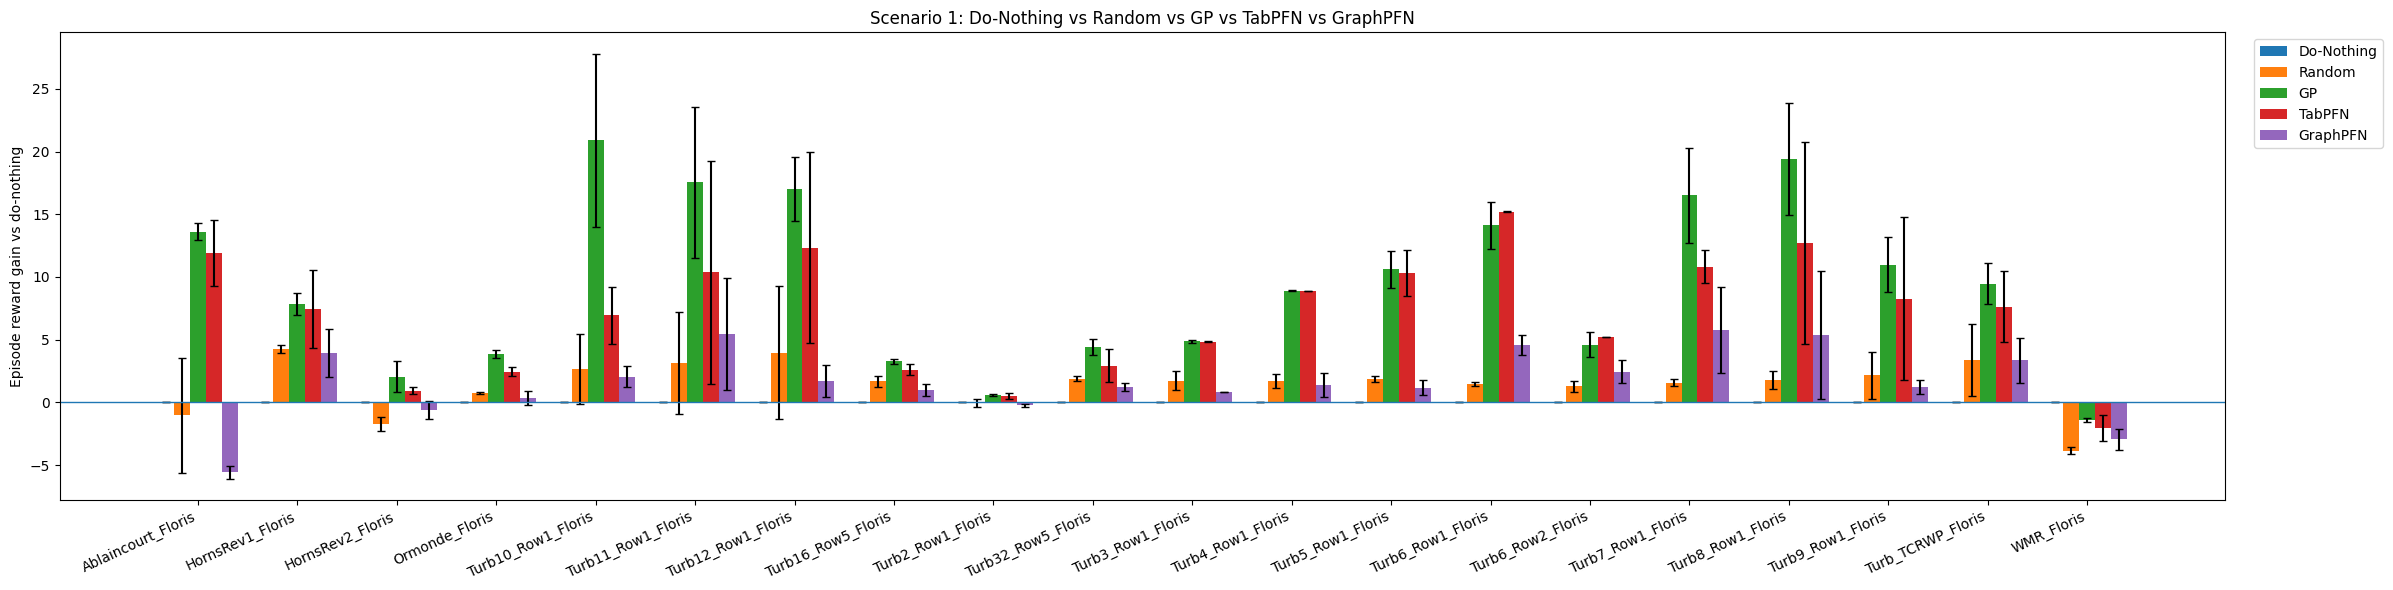

In [15]:
method_order = ["Do-Nothing", "Random", "GP", "TabPFN", "GraphPFN"]
layout_order = list(summary_df["layout"].drop_duplicates())

fig, ax = plt.subplots(figsize=(max(10, 1.2 * len(layout_order)), 6))
width = 0.16
x = np.arange(len(layout_order))

for i, method in enumerate(method_order):
    sub = summary_df[summary_df["method"] == method].set_index("layout").reindex(layout_order)
    ax.bar(
        x + (i - (len(method_order) - 1) / 2) * width,
        sub["mean_gain"].values,
        width=width,
        yerr=sub["std_gain"].values,
        capsize=3,
        label=method,
    )

ax.axhline(0.0, linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(layout_order, rotation=25, ha="right")
ax.set_ylabel("Episode reward gain vs do-nothing")
ax.set_title("Scenario 1: Do-Nothing vs Random vs GP vs TabPFN vs GraphPFN")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0))
plt.tight_layout()
plt.show()